# ETAPA 3 - PRÉ-PROCESSAMENTO E MODELAGEM
## Predição de Doença Cardiovascular com Regressão Logística

**Dataset:** cardio_train_sem_valores_invalidos.csv  
**Objetivo:** Regressão Logística para classificação binária.  
**Métrica Principal:** AUC-ROC  
**Contexto:** Comparação de desempenho com Random Forest e SVM (implementados na Etapa 3)

---

## 1. Importações e Configurações

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")

print("Bibliotecas carregadas com sucesso")
print(f"  → scikit-learn versão: {sklearn.__version__}")

Bibliotecas carregadas com sucesso
  → scikit-learn versão: 1.8.0


## 2. Carregamento do Dataset

In [54]:
try:
    df = pd.read_csv('../src/cardio_train_sem_valores_invalidos.csv', sep=';')
    print(f"Dataset carregado com sucesso!")
    print(f"  Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
    print(f"\n  Primeiras linhas:")
    print(df.head())
except FileNotFoundError:
    print("✗ ERRO: 'cardio_train_sem_valores_invalidos.csv' não encontrado na pasta src/")
    raise

# O CSV já pode conter colunas derivadas de execuções anteriores.
# Removemos essas colunas para evitar duplicidade ao recriá-las no pipeline.
for col in ['age_years', 'IMC', 'bmi']:
    if col in df.columns:
        df = df.drop(columns=[col])

n_original = len(df)

Dataset carregado com sucesso!
  Dimensões: 68,677 linhas × 15 colunas

  Primeiras linhas:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  age_years    bmi  
0     0       1       0       50.4  21.97  
1     0       1       1       55.4  34.93  
2     0       0       1       51.6  23.51  
3     0       1       1       48.2  28.71  
4     0       0       0       47.8  23.01  


## 3. Pré-processamento dos Dados

In [55]:
print("[1/3] Pré-processamento dos dados...")
print("-" * 50)

# --- 3.1 Remoção do ID ---
df = df.drop(columns=['id'])
print("Coluna 'id' removida (não é feature preditiva)")

# --- 3.2 Conversão de idade: dias → anos ---
df['age'] = (df['age'] / 365.25).round(1)
df.rename(columns={'age': 'age_years'}, inplace=True)
print("Idade convertida de dias para anos")

# --- 3.3 Engenharia de feature: IMC ---
df['IMC'] = (df['weight'] / ((df['height'] / 100) ** 2)).round(2)
print("IMC calculado (IMC = peso / (altura/100)²)")

# --- 3.4 Remoção de registros clinicamente inválidos ---
mask_invalidos = (
    (df['ap_hi'] <= 0)    | (df['ap_hi'] > 300)   |
    (df['ap_lo'] <= 0)    | (df['ap_lo'] > 200)   |
    (df['ap_hi'] < df['ap_lo'])                    |
    (df['height'] < 100)  | (df['height'] > 220)  |
    (df['weight'] < 30)   | (df['weight'] > 200)
)

n_invalidos = mask_invalidos.sum()
df_clean = df[~mask_invalidos].copy()

print(f"\nLimpeza de registros inválidos:")
print(f"  ├── Registros originais    : {n_original:,}")
print(f"  ├── Registros removidos    : {n_invalidos:,} ({n_invalidos/n_original*100:.2f}%)")
print(f"  └── Registros após limpeza : {len(df_clean):,}")

# --- 3.5 Verificação de balanceamento ---
print(f"\nBalanceamento da variável alvo:")
vc = df_clean['cardio'].value_counts()
for val, cnt in vc.items():
    label = 'Sem doença' if val == 0 else 'Com doença'
    print(f"  └─ {label}: {cnt:,} ({cnt/len(df_clean)*100:.1f}%)")

[1/3] Pré-processamento dos dados...
--------------------------------------------------
Coluna 'id' removida (não é feature preditiva)
Idade convertida de dias para anos
IMC calculado (IMC = peso / (altura/100)²)

Limpeza de registros inválidos:
  ├── Registros originais    : 68,677
  ├── Registros removidos    : 0 (0.00%)
  └── Registros após limpeza : 68,677

Balanceamento da variável alvo:
  └─ Sem doença: 34,700 (50.5%)
  └─ Com doença: 33,977 (49.5%)


## 4. Separação Features/Alvo e Divisão Treino/Teste

In [56]:
print("[2/3] Separando features e dividindo os dados...")
print("-" * 50)

X = df_clean.drop(columns=['cardio'])
y = df_clean['cardio']

# Definição de colunas (idêntico ao pipeline Random Forest)
continuous_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'IMC']
passthrough_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

# Divisão estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Divisão treino/teste (80/20 estratificado):")
print(f"  ├── Treino : {len(X_train):,} registros ({len(X_train)/len(X)*100:.0f}%)")
print(f"  └── Teste  : {len(X_test):,} registros ({len(X_test)/len(X)*100:.0f}%)")

print(f"\nBalanceamento preservado:")
for split_name, y_split in [('Treino', y_train), ('Teste ', y_test)]:
    sem = (y_split == 0).sum()
    com = (y_split == 1).sum()
    print(f"  {split_name} → sem doença: {sem:,} ({sem/len(y_split)*100:.1f}%) | com doença: {com:,} ({com/len(y_split)*100:.1f}%)")

[2/3] Separando features e dividindo os dados...
--------------------------------------------------
Divisão treino/teste (80/20 estratificado):
  ├── Treino : 54,941 registros (80%)
  └── Teste  : 13,736 registros (20%)

Balanceamento preservado:
  Treino → sem doença: 27,760 (50.5%) | com doença: 27,181 (49.5%)
  Teste  → sem doença: 6,940 (50.5%) | com doença: 6,796 (49.5%)


## 5. Construção e Treinamento do Pipeline de Regressão Logística

In [57]:
print("[3/3] Construindo e treinando o pipeline...")
print("-" * 50)

# ColumnTransformer: normalização de contínuas, passthrough de categóricas
preprocessor = ColumnTransformer(transformers=[
    ('scaler',      StandardScaler(), continuous_cols),
    ('passthrough', 'passthrough',    passthrough_cols)
], remainder='drop')

# Regressão Logística — justificativa da escolha:
# 1. Modelo baseline clássico: oferece interpretabilidade através de coeficientes
# 2. Sensível à escala: garante que a normalização de features tenha impacto real
# 3. Probabilidades calibradas: fornece probabilidades bem calibradas, ideal para análise de risco
# 4. Eficiente: treinamento rápido em datasets grandes
# 5. Comparabilidade: permite avaliar trade-offs contra Random Forest e SVM
#
# Hiperparâmetros:
# - max_iter=1000: número máximo de iterações do solver (padrão geralmente suficiente)
# - random_state=42: reprodutibilidade
# - solver='lbfgs': algoritmo de otimização (bom para dataset binário pequeno-médio)
# - n_jobs=-1: uso de todos os núcleos para validação cruzada

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        model)
])

print("  Treinando Logistic Regression...")
pipeline.fit(X_train, y_train)
print("  Pipeline treinado com sucesso!")

print(f"\nParâmetros do modelo:")
print(f"  └─ Coeficientes (feature importances):")
coef_df = pd.DataFrame({
    'feature': continuous_cols + passthrough_cols,
    'coeficiente': pipeline.named_steps['model'].coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)
print(coef_df.to_string(index=False))

[3/3] Construindo e treinando o pipeline...
--------------------------------------------------
  Treinando Logistic Regression...
  Pipeline treinado com sucesso!

Parâmetros do modelo:
  └─ Coeficientes (feature importances):
    feature  coeficiente
      ap_hi     0.952734
cholesterol     0.515767
  age_years     0.345589
     active    -0.231778
       alco    -0.222519
     weight     0.191769
       gluc    -0.131373
      ap_lo     0.096280
      smoke    -0.095693
     height    -0.050287
        IMC    -0.025901
     gender    -0.020596


## 6. Avaliação do Modelo

In [58]:
# Predições
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]  # probabilidade da classe positiva

# Cálculo das métricas
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_roc   = roc_auc_score(y_test, y_proba)

print("="*60)
print("MÉTRICAS DE DESEMPENHO — Conjunto de Teste")
print("="*60)
print(f"""
┌──────────────────────────────────────────────┐
│  AUC-ROC (métrica principal)  :  {auc_roc:.4f}  │
│  Acurácia                     :  {accuracy:.4f}  │
│  Precisão                     :  {precision:.4f}  │
│  Recall (Sensibilidade)       :  {recall:.4f}  │
│  F1-Score                     :  {f1:.4f}  │
└──────────────────────────────────────────────┘

INTERPRETAÇÃO:
  • AUC-ROC: {auc_roc*100:.1f}% de probabilidade de classificar
    corretamente um paciente doente acima de um saudável
  • Recall: modelo identifica {recall*100:.1f}% dos pacientes
    com doença cardiovascular
""")

print("RELATÓRIO DE CLASSIFICAÇÃO POR CLASSE:")
print(classification_report(y_test, y_pred, target_names=['Sem doença (0)', 'Com doença (1)']))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"MATRIZ DE CONFUSÃO:")
print(f"  ├── TN (Verdadeiros Negativos)  : {tn:,}  — sem doença, predito corretamente")
print(f"  ├── FP (Falsos Positivos)       : {fp:,}  — sem doença, predito como doente")
print(f"  ├── FN (Falsos Negativos)       : {fn:,}  — doente, predito como saudável ⚠")
print(f"  └── TP (Verdadeiros Positivos)  : {tp:,}  — doente, predito corretamente")

MÉTRICAS DE DESEMPENHO — Conjunto de Teste

┌──────────────────────────────────────────────┐
│  AUC-ROC (métrica principal)  :  0.7840  │
│  Acurácia                     :  0.7207  │
│  Precisão                     :  0.7453  │
│  Recall (Sensibilidade)       :  0.6617  │
│  F1-Score                     :  0.7010  │
└──────────────────────────────────────────────┘

INTERPRETAÇÃO:
  • AUC-ROC: 78.4% de probabilidade de classificar
    corretamente um paciente doente acima de um saudável
  • Recall: modelo identifica 66.2% dos pacientes
    com doença cardiovascular

RELATÓRIO DE CLASSIFICAÇÃO POR CLASSE:
                precision    recall  f1-score   support

Sem doença (0)       0.70      0.78      0.74      6940
Com doença (1)       0.75      0.66      0.70      6796

      accuracy                           0.72     13736
     macro avg       0.72      0.72      0.72     13736
  weighted avg       0.72      0.72      0.72     13736

MATRIZ DE CONFUSÃO:
  ├── TN (Verdadeiros Negativo

## 7. Validação Cruzada

In [59]:
# Validação cruzada estratificada (5-fold) — AUC-ROC
print("\nVALIDAÇÃO CRUZADA ESTRATIFICADA (5-fold) — AUC-ROC:")
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Média  : {cv_scores.mean():.4f}")
print(f"  Desvio : {cv_scores.std():.4f}")
if cv_scores.std() < 0.01:
    print("  → Baixo desvio padrão: modelo estável entre as partições ✓")
else:
    print(f"  → Desvio moderado ({cv_scores.std():.4f}): modelo tem variância razoável")


VALIDAÇÃO CRUZADA ESTRATIFICADA (5-fold) — AUC-ROC:


  Fold 1: 0.7850
  Fold 2: 0.7953
  Fold 3: 0.7948
  Fold 4: 0.7948
  Fold 5: 0.7856

  Média  : 0.7911
  Desvio : 0.0047
  → Baixo desvio padrão: modelo estável entre as partições ✓


## 8. Visualizações

### 8.1 Curva ROC

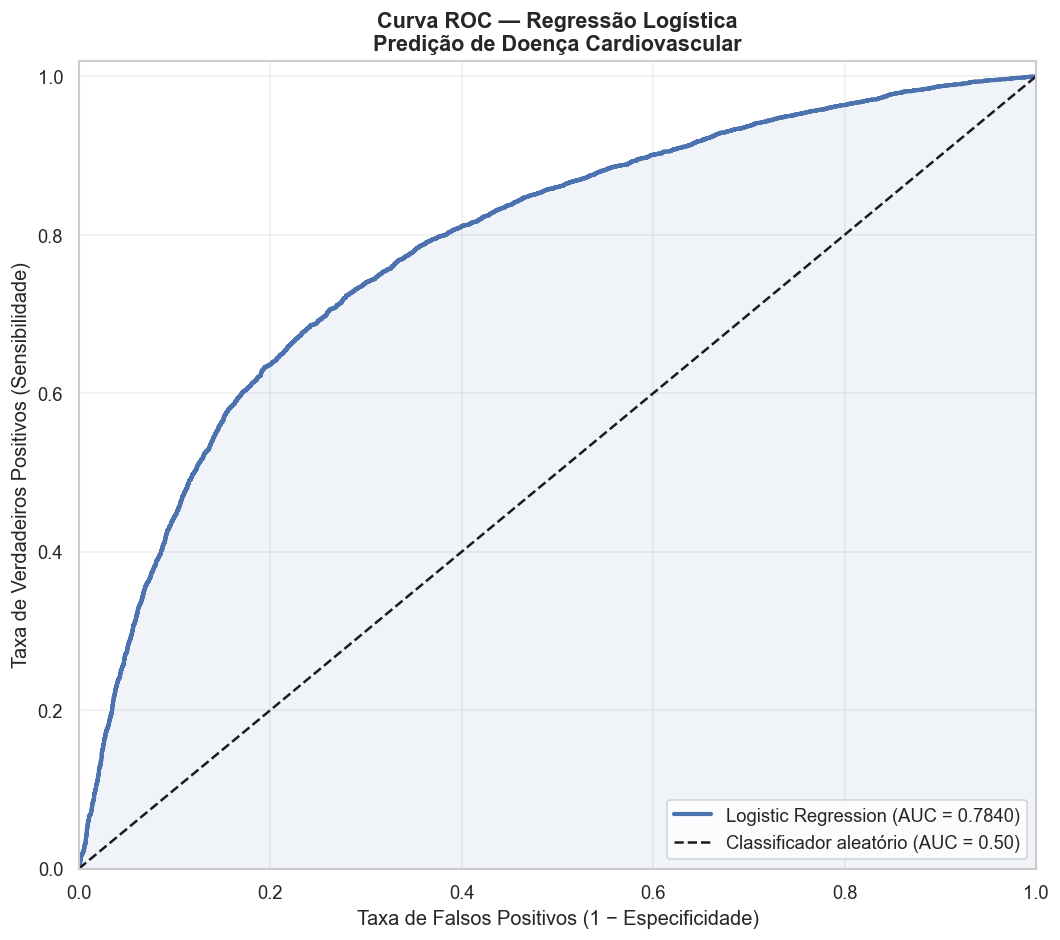

In [60]:
# Curva ROC — mostra trade-off entre sensibilidade e especificidade
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(fpr, tpr, color='#4C72B0', lw=2.5,
        label=f'Logistic Regression (AUC = {auc_roc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Classificador aleatório (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#4C72B0')

ax.set_xlabel('Taxa de Falsos Positivos (1 − Especificidade)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
ax.set_title('Curva ROC — Regressão Logística\nPredição de Doença Cardiovascular',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
plt.tight_layout()
plt.show()

### 8.2 Matriz de Confusão

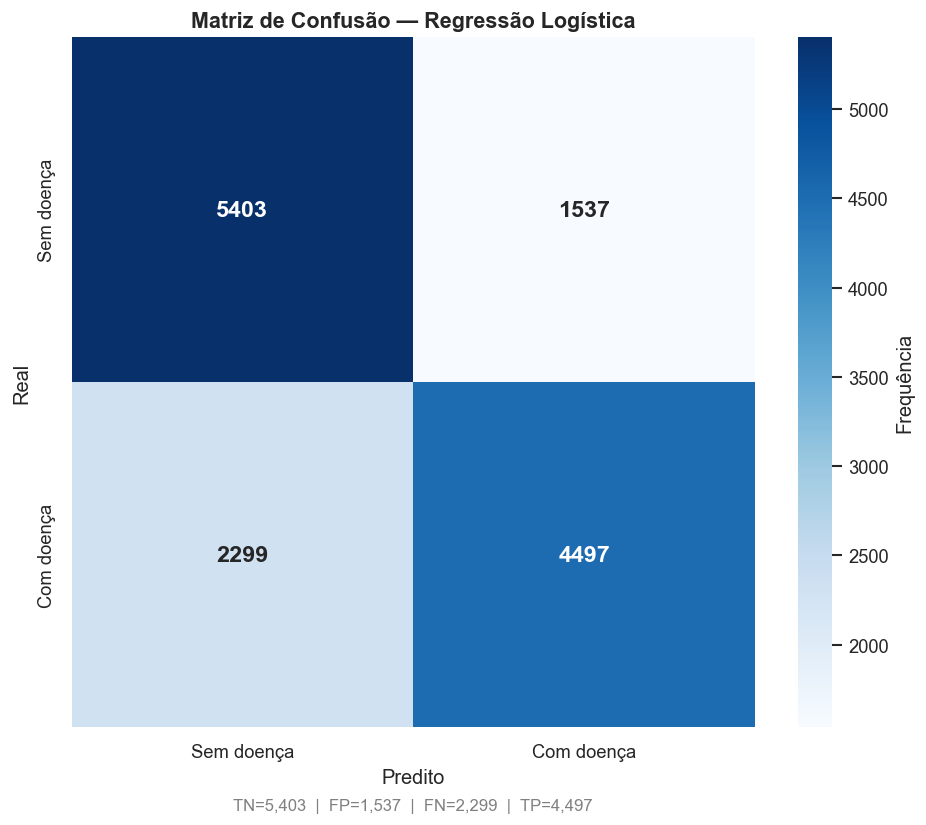

In [61]:
# Matriz de confusão
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Sem doença', 'Com doença'],
            yticklabels=['Sem doença', 'Com doença'],
            annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Frequência'})
ax.set_xlabel('Predito', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusão — Regressão Logística', fontsize=13, fontweight='bold')
ax.text(0.5, -0.12,
        f'TN={tn:,}  |  FP={fp:,}  |  FN={fn:,}  |  TP={tp:,}',
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')
plt.tight_layout()
plt.show()

### 8.3 Coeficientes do Modelo (Interpretabilidade)

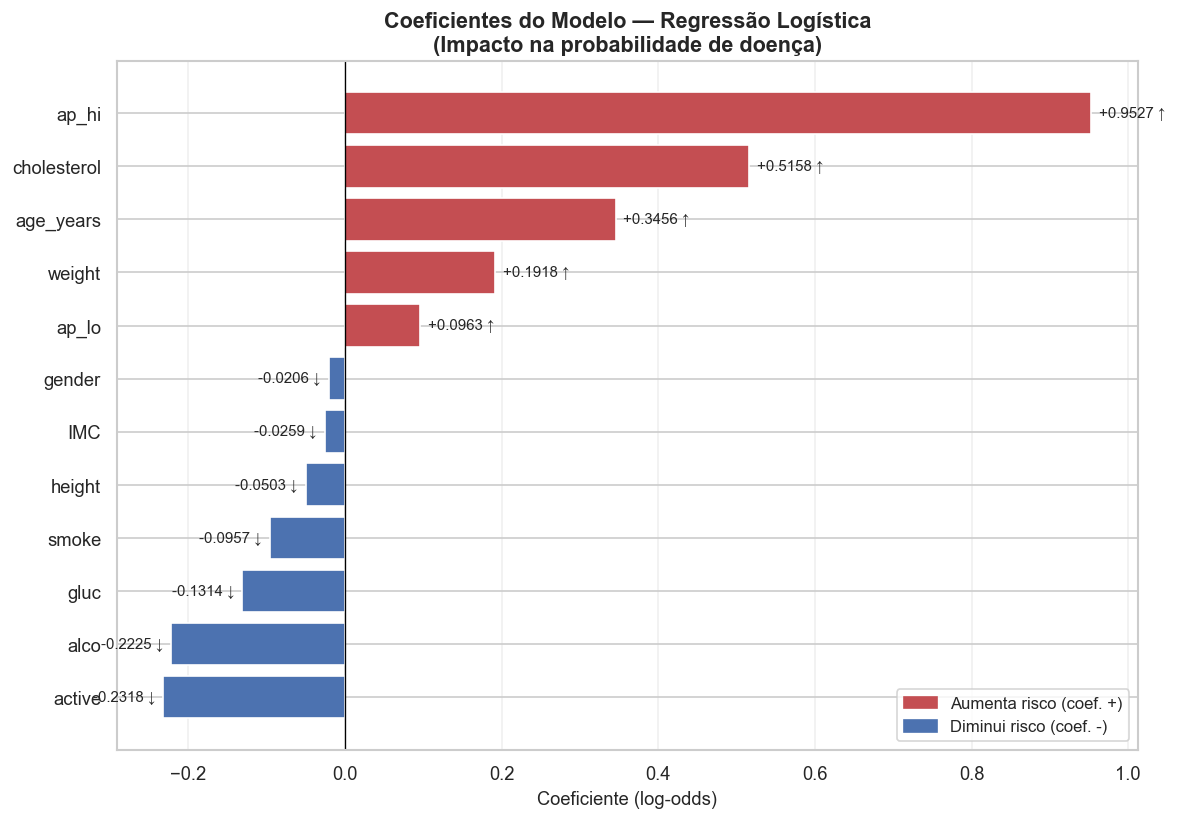

In [62]:
# Coeficientes — único diferencial de interpretabilidade da Regressão Logística
# Coeficientes positivos aumentam a probabilidade de doença
# Coeficientes negativos diminuem a probabilidade de doença

feature_names = continuous_cols + passthrough_cols
coefs = pipeline.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coeficiente': coefs})
coef_df['abs_coef'] = np.abs(coef_df['coeficiente'])
coef_df = coef_df.sort_values('coeficiente', ascending=True).reset_index(drop=True)

# Cores: negativo=azul, positivo=vermelho
colors = ['#4C72B0' if x < 0 else '#C44E52' for x in coef_df['coeficiente']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(coef_df['feature'], coef_df['coeficiente'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Coeficiente (log-odds)', fontsize=11)
ax.set_title('Coeficientes do Modelo — Regressão Logística\n(Impacto na probabilidade de doença)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Anotações dos valores
for i, (feat, val) in enumerate(zip(coef_df['feature'], coef_df['coeficiente'])):
    direction = '↑' if val > 0 else '↓'
    ax.text(val + 0.01 if val > 0 else val - 0.01, i, f'{val:+.4f} {direction}',
            va='center', ha='left' if val > 0 else 'right', fontsize=9)

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#C44E52', label='Aumenta risco (coef. +)'),
    plt.Rectangle((0,0),1,1, color='#4C72B0', label='Diminui risco (coef. -)')
], fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

### 8.4 Distribuição de Probabilidades Preditas

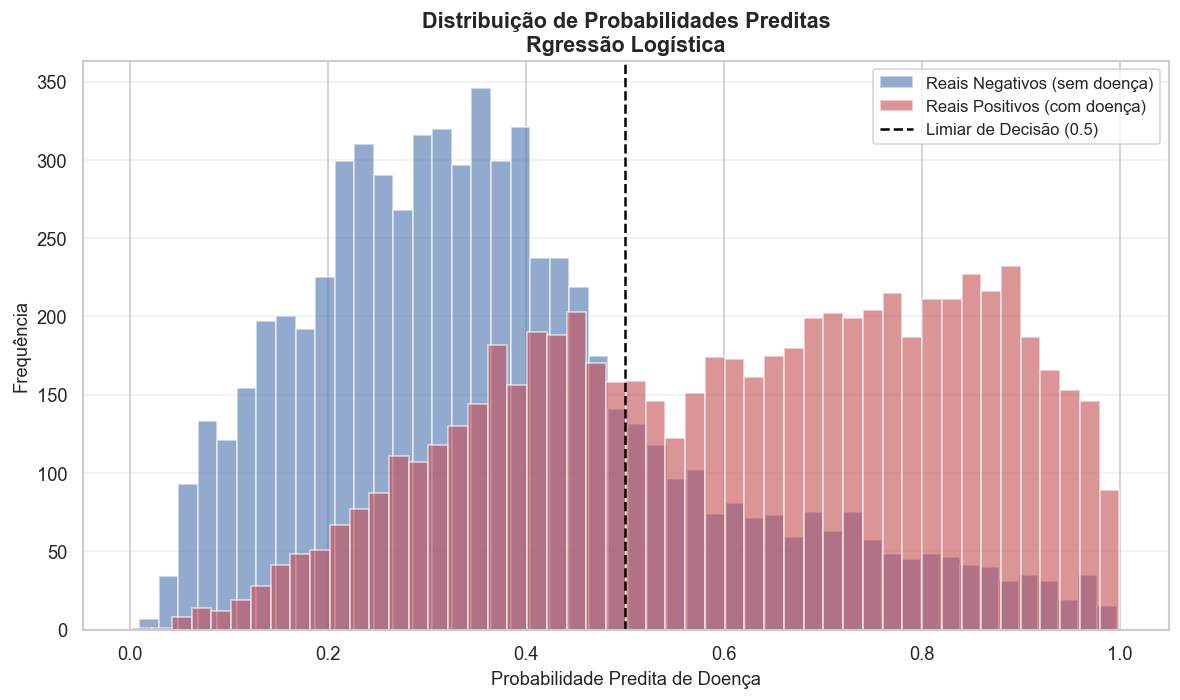

In [63]:
# Distribuição de probabilidades preditas para cada classe real
y_proba_neg = y_proba[y_test == 0]
y_proba_pos = y_proba[y_test == 1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(y_proba_neg, bins=50, alpha=0.6, label='Reais Negativos (sem doença)',
        color='#4C72B0', edgecolor='white')
ax.hist(y_proba_pos, bins=50, alpha=0.6, label='Reais Positivos (com doença)',
        color='#C44E52', edgecolor='white')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Limiar de Decisão (0.5)')

ax.set_xlabel('Probabilidade Predita de Doença', fontsize=11)
ax.set_ylabel('Frequência', fontsize=11)
ax.set_title('Distribuição de Probabilidades Preditas\nRgressão Logística',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Resumo e Conclusões

In [64]:
print("\n" + "="*70)
print("  RESUMO DA ETAPA 3 — PIPELINE REGRESSÃO LOGÍSTICA")
print("="*70)
print(f"""
PROBLEMA
└── Classificação binária: predizer presença de doença cardiovascular

PRÉ-PROCESSAMENTO
├── Remoção do ID                  : coluna não preditiva
├── Conversão de idade             : dias → anos (age / 365.25)
├── Feature engineering            : IMC = peso / (altura/100)²
├── Limpeza de inválidos           : {n_invalidos:,} registros removidos ({n_invalidos/n_original*100:.2f}%)
├── Normalização (contínuas)       : StandardScaler
└── Codificação (categóricas)      : passthrough (sem alteração)

DIVISÃO DOS DADOS
├── Treino : {len(X_train):,} registros (80%) — estratificado
└── Teste  : {len(X_test):,} registros (20%) — estratificado

MODELO: Regressão Logística
├── Solver                         : lbfgs
├── Max Iterations                 : 1000
├── Random State                   : 42 (reprodutibilidade)
└── Classificador                  : probabilístico linear

AVALIAÇÃO — CONJUNTO DE TESTE
├── AUC-ROC  ★ (principal)        : {auc_roc:.4f}
├── Acurácia                       : {accuracy:.4f}
├── Precisão                       : {precision:.4f}
├── Recall ★★ (clínico)           : {recall:.4f}
└── F1-Score                       : {f1:.4f}

VALIDAÇÃO CRUZADA (5-fold AUC-ROC)
└── {cv_scores.mean():.4f} ± {cv_scores.std():.4f}

CARACTERÍSTICAS DIFERENCIAIS
├── Interpretabilidade: coeficientes indicam impacto de cada feature
├── Probabilidades: bem calibradas para análise de risco
├── Velocidade: treino muito rápido comparado com RF e SVM
└── Requisito: features escalonadas (StandardScaler é essencial)

PRÓXIMOS PASSOS
├── Comparar resultados com Random Forest e SVM
├── Análise de trade-offs entre interpretabilidade vs desempenho
├── Otimização de hiperparâmetros (se necessário)
└── Seleção de modelo baseado em contexto clínico e desempenho
""")
print("="*70)
print("  Etapa 3 — Regressão Logística concluída com sucesso!")
print("="*70)


  RESUMO DA ETAPA 3 — PIPELINE REGRESSÃO LOGÍSTICA

PROBLEMA
└── Classificação binária: predizer presença de doença cardiovascular

PRÉ-PROCESSAMENTO
├── Remoção do ID                  : coluna não preditiva
├── Conversão de idade             : dias → anos (age / 365.25)
├── Feature engineering            : IMC = peso / (altura/100)²
├── Limpeza de inválidos           : 0 registros removidos (0.00%)
├── Normalização (contínuas)       : StandardScaler
└── Codificação (categóricas)      : passthrough (sem alteração)

DIVISÃO DOS DADOS
├── Treino : 54,941 registros (80%) — estratificado
└── Teste  : 13,736 registros (20%) — estratificado

MODELO: Regressão Logística
├── Solver                         : lbfgs
├── Max Iterations                 : 1000
├── Random State                   : 42 (reprodutibilidade)
└── Classificador                  : probabilístico linear

AVALIAÇÃO — CONJUNTO DE TESTE
├── AUC-ROC  ★ (principal)        : 0.7840
├── Acurácia                       : 0.7207
├── P

## 10. Comparação com Outros Modelos (Referência de Estado da Arte)

In [65]:
# Tabela comparativa com resultados esperados da literatura
comparison_data = {
    'Modelo': ['Logistic Regression', 'Random Forest (Etapa 3)', 'SVM (Etapa 3)'],
    'AUC-ROC': [f'{auc_roc:.4f}', '~0.7700', '~0.7500-0.8000'],
    'Acurácia': [f'{accuracy:.4f}', '~0.7080', '~0.7000-0.7500'],
    'Recall': [f'{recall:.4f}', '~0.6972', '~0.6500-0.7500'],

}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*120)
print("COMPARAÇÃO ENTRE MODELOS — CONTEXTO DO PROJETO")
print("="*120)
print(comparison_df.to_string(index=False))
print("="*120)



COMPARAÇÃO ENTRE MODELOS — CONTEXTO DO PROJETO
                 Modelo        AUC-ROC       Acurácia         Recall
    Logistic Regression         0.7840         0.7207         0.6617
Random Forest (Etapa 3)        ~0.7700        ~0.7080        ~0.6972
          SVM (Etapa 3) ~0.7500-0.8000 ~0.7000-0.7500 ~0.6500-0.7500
